Processing 1974 edge pixels...
Found 9 lines


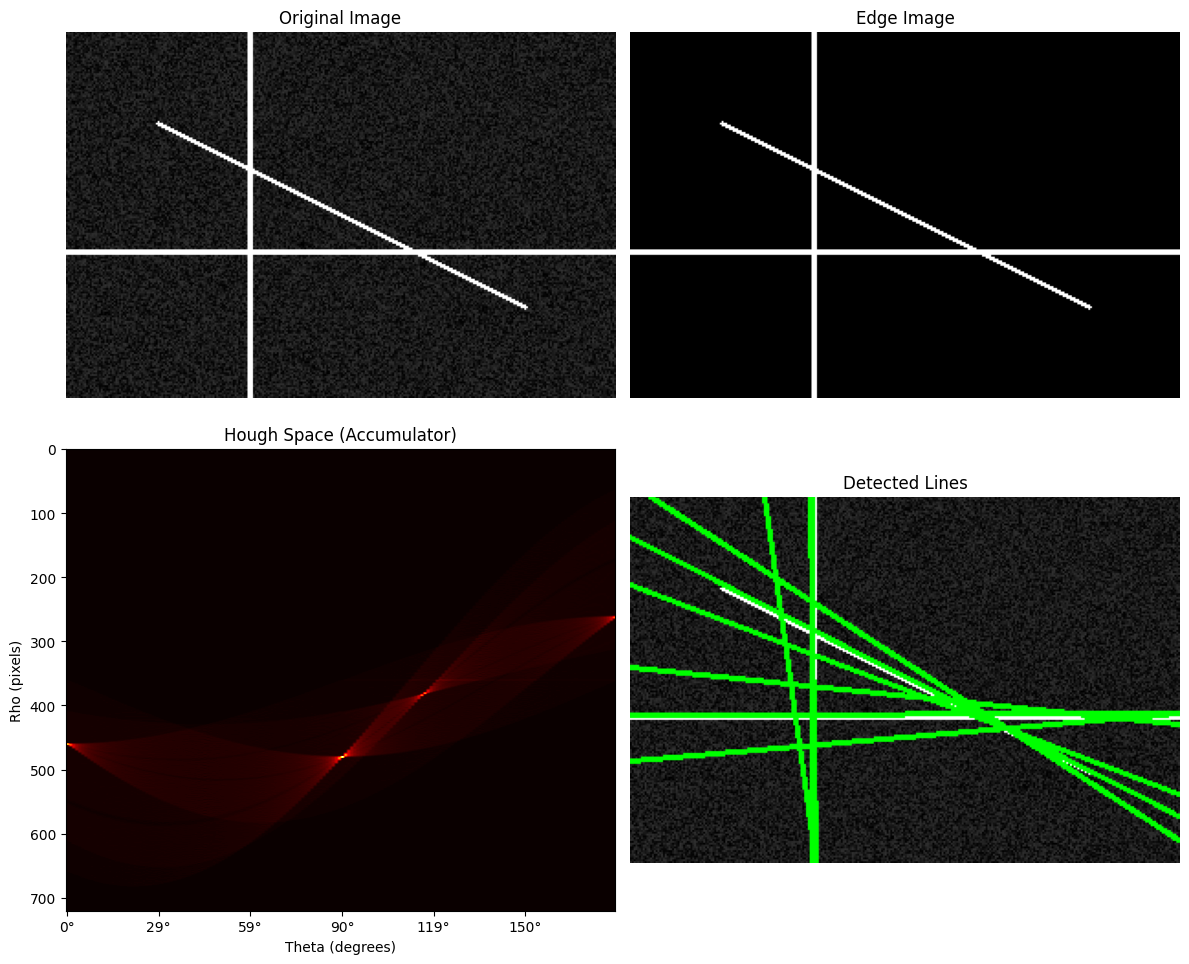


Detected Lines:
Rho (pixels) | Theta (degrees) | Votes
----------------------------------------
   119.0 |        90.0° |   300
    99.0 |         0.0° |   200
    20.0 |       117.0° |   192
   -98.0 |       179.0° |   172
    93.0 |        96.0° |    40
   144.0 |        85.0° |    38
    45.0 |       111.0° |    36
   -73.0 |       172.0° |    30
    -6.0 |       123.0° |    30


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import cv2

class SimpleHoughTransform:
    def __init__(self, rho_resolution=1, theta_resolution=np.pi/180):
        """
        Simple Hough Transform for line detection
        
        Args:
            rho_resolution: Distance resolution in pixels
            theta_resolution: Angle resolution in radians
        """
        self.rho_resolution = rho_resolution
        self.theta_resolution = theta_resolution
        
    def hough_transform(self, edge_image):
        """
        Perform Hough Transform on edge image
        
        Args:
            edge_image: Binary edge image (0s and 255s)
            
        Returns:
            accumulator: Hough space accumulator array
            thetas: Array of theta values
            rhos: Array of rho values
        """
        height, width = edge_image.shape
        
        # Define parameter space
        # Theta: 0 to π (0 to 180 degrees)
        thetas = np.arange(0, np.pi, self.theta_resolution)
        
        # Rho: maximum possible distance is diagonal of image
        max_rho = int(np.sqrt(width**2 + height**2))
        rhos = np.arange(-max_rho, max_rho + 1, self.rho_resolution)
        
        # Initialize accumulator
        accumulator = np.zeros((len(rhos), len(thetas)), dtype=np.uint64)
        
        # Find edge pixels (non-zero pixels)
        edge_pixels = np.where(edge_image > 0)
        
        print(f"Processing {len(edge_pixels[0])} edge pixels...")
        
        # For each edge pixel
        for i in range(len(edge_pixels[0])):
            y, x = edge_pixels[0][i], edge_pixels[1][i]
            
            # For each possible theta
            for theta_idx, theta in enumerate(thetas):
                # Calculate rho using: x*cos(theta) + y*sin(theta) = rho
                rho = int(x * np.cos(theta) + y * np.sin(theta))
                
                # Find rho index in our array
                rho_idx = np.argmin(np.abs(rhos - rho))
                
                # Vote in accumulator
                accumulator[rho_idx, theta_idx] += 1
        
        return accumulator, thetas, rhos
    
    def find_peaks(self, accumulator, threshold, min_distance=50):
        """
        Find peaks in accumulator array
        
        Args:
            accumulator: Hough space accumulator
            threshold: Minimum votes for a line
            min_distance: Minimum distance between peaks
            
        Returns:
            peaks: List of (rho_idx, theta_idx, votes) tuples
        """
        peaks = []
        
        # Create a copy for peak suppression
        acc_copy = accumulator.copy()
        
        while True:
            # Find global maximum
            max_idx = np.unravel_index(np.argmax(acc_copy), acc_copy.shape)
            max_votes = acc_copy[max_idx]
            
            if max_votes < threshold:
                break
                
            rho_idx, theta_idx = max_idx
            peaks.append((rho_idx, theta_idx, max_votes))
            
            # Suppress nearby peaks
            rho_start = max(0, rho_idx - min_distance//2)
            rho_end = min(acc_copy.shape[0], rho_idx + min_distance//2)
            theta_start = max(0, theta_idx - min_distance//2)
            theta_end = min(acc_copy.shape[1], theta_idx + min_distance//2)
            
            acc_copy[rho_start:rho_end, theta_start:theta_end] = 0
            
            if len(peaks) >= 10:  # Limit number of lines
                break
                
        return peaks
    
    def draw_lines(self, image, peaks, thetas, rhos):
        """
        Draw detected lines on image
        
        Args:
            image: Original image
            peaks: Detected peaks from find_peaks
            thetas: Theta values array
            rhos: Rho values array
            
        Returns:
            result_image: Image with lines drawn
        """
        result = image.copy()
        if len(result.shape) == 2:  # Convert grayscale to RGB
            result = cv2.cvtColor(result, cv2.COLOR_GRAY2RGB)
            
        height, width = image.shape[:2]
        
        for rho_idx, theta_idx, votes in peaks:
            rho = rhos[rho_idx]
            theta = thetas[theta_idx]
            
            # Convert line parameters to start and end points
            cos_theta = np.cos(theta)
            sin_theta = np.sin(theta)
            
            # Find two points on the line within image bounds
            points = []
            
            # Check intersections with image boundaries
            # Left edge (x = 0)
            if sin_theta != 0:
                y = rho / sin_theta
                if 0 <= y <= height:
                    points.append((0, int(y)))
            
            # Right edge (x = width-1)
            if sin_theta != 0:
                y = (rho - (width-1) * cos_theta) / sin_theta
                if 0 <= y <= height:
                    points.append((width-1, int(y)))
            
            # Top edge (y = 0)
            if cos_theta != 0:
                x = rho / cos_theta
                if 0 <= x <= width:
                    points.append((int(x), 0))
            
            # Bottom edge (y = height-1)
            if cos_theta != 0:
                x = (rho - (height-1) * sin_theta) / cos_theta
                if 0 <= x <= width:
                    points.append((int(x), height-1))
            
            # Draw line if we have at least 2 points
            if len(points) >= 2:
                pt1, pt2 = points[0], points[1]
                cv2.line(result, pt1, pt2, (0, 255, 0), 2)
                
        return result

# Demo function
def demo_hough_transform():
    """
    Demonstrate the Hough Transform with a simple test image
    """
    # Create a simple test image with lines
    img = np.zeros((200, 300), dtype=np.uint8)
    
    # Draw some lines
    cv2.line(img, (50, 50), (250, 150), 255, 2)   # Diagonal line
    cv2.line(img, (100, 0), (100, 200), 255, 2)   # Vertical line  
    cv2.line(img, (0, 120), (300, 120), 255, 2)   # Horizontal line
    
    # Add some noise
    noise = np.random.randint(0, 50, (200, 300))
    img = np.clip(img.astype(int) + noise, 0, 255).astype(np.uint8)
    
    # Apply edge detection (simple threshold in this case)
    edges = np.where(img > 150, 255, 0).astype(np.uint8)
    
    # Apply Hough Transform
    hough = SimpleHoughTransform(rho_resolution=1, theta_resolution=np.pi/180)
    accumulator, thetas, rhos = hough.hough_transform(edges)
    
    # Find peaks
    peaks = hough.find_peaks(accumulator, threshold=30)
    print(f"Found {len(peaks)} lines")
    
    # Draw results
    result_img = hough.draw_lines(img, peaks, thetas, rhos)
    
    # Create visualization
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # Original image
    axes[0,0].imshow(img, cmap='gray')
    axes[0,0].set_title('Original Image')
    axes[0,0].axis('off')
    
    # Edge image
    axes[0,1].imshow(edges, cmap='gray')
    axes[0,1].set_title('Edge Image')
    axes[0,1].axis('off')
    
    # Hough space (accumulator)
    axes[1,0].imshow(accumulator, cmap='hot', aspect='auto')
    axes[1,0].set_title('Hough Space (Accumulator)')
    axes[1,0].set_xlabel('Theta (degrees)')
    axes[1,0].set_ylabel('Rho (pixels)')
    
    # Set proper tick labels
    theta_ticks = np.arange(0, len(thetas), len(thetas)//6)
    theta_labels = [f'{int(np.degrees(thetas[i]))}°' for i in theta_ticks]
    axes[1,0].set_xticks(theta_ticks)
    axes[1,0].set_xticklabels(theta_labels)
    
    # Result with detected lines
    axes[1,1].imshow(result_img)
    axes[1,1].set_title('Detected Lines')
    axes[1,1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Print detected line parameters
    print("\nDetected Lines:")
    print("Rho (pixels) | Theta (degrees) | Votes")
    print("-" * 40)
    for rho_idx, theta_idx, votes in peaks:
        rho_val = rhos[rho_idx]
        theta_deg = np.degrees(thetas[theta_idx])
        print(f"{rho_val:8.1f} | {theta_deg:11.1f}° | {votes:5d}")

# Run the demo
if __name__ == "__main__":
    demo_hough_transform()